In [3]:
"""
============================================================
Traffic Light Scheduling Optimization
============================================================

Project Goal:
The goal of this project is to design and implement algorithms to optimize
traffic-light scheduling at a single 4-way intersection, with the objective
of minimizing vehicle queues and wait times on all approaches. Each lane
will have a known vehicle arrival rate, and traffic lights must satisfy
operational constraints, including minimum and maximum green durations and
mandatory yellow-light intervals during every phase change. The system will
evaluate greedy, sorting-based, and dynamic programming algorithms.
"""

# ==========================================
# Imports
# ==========================================
from dataclasses import dataclass, field
from enum import Enum
from typing import Callable, Optional, Dict, Any, List
import matplotlib.pyplot as plt

In [4]:
# ==========================================
# Phase Enumeration
# ==========================================
class Phase(str, Enum):
    GREEN = "GREEN"
    YELLOW = "YELLOW"
    RED = "RED"


# ======================================================================
# Lane Class:
# id identifies directions, queue tracks waiting vehicles,
# arrival_function determines vehicle arrival
# update_arrivals increments queue by 1 if a vehicle arrives at time t
# ======================================================================
@dataclass
class Lane:
    id: str
    queue: int
    arrival_function: Callable[[int], bool]

    def update_arrivals(self, t: int) -> None:
        if self.arrival_function(t):
            self.queue += 1


# ============================================================================
# Traffic Signal Class:
# current_lane checks which lane has the green light, current_phase checks RGY
# green_elapsed checks how long the green light has been active
# yellow_remaining checks how much yellow time remains
# reset_for_new_lane transitions into a new lane, resets phase to green
# ============================================================================
@dataclass
class TrafficSignal:
    current_lane: Optional[str]
    current_phase: Phase
    green_elapsed: int
    yellow_remaining: int

    def reset_for_new_lane(self, lane_id: str) -> None:
        self.current_lane = lane_id
        self.current_phase = Phase.GREEN
        self.green_elapsed = 0
        self.yellow_remaining = 0

In [5]:
# ==========================================
# Simulation Parameters
# ==========================================
@dataclass
class SimulationParameters:
    lane_ids: List[str]
    simulation_duration: int
    min_green_time: int
    max_green_time: int
    yellow_duration: int


# ==========================================
# History Recording
# ==========================================
@dataclass
class SimulationHistory:
    time_steps: List[int] = field(default_factory=list)
    queue_lengths: List[Dict[str, int]] = field(default_factory=list)
    phase_history: List[Dict[str, Any]] = field(default_factory=list)


# ==========================================
# Simulator Class
# ==========================================
@dataclass
class Simulator:
    params: SimulationParameters
    lanes: Dict[str, Lane]
    signal: TrafficSignal
    time: int = 0
    history: SimulationHistory = field(default_factory=SimulationHistory)

    # ----------------------
    # One simulation step
    # ----------------------
    def step(self, decision: Optional[Dict[str, Any]] = None) -> None:
        """
        Performs one time step using:
        - arrival rules
        - departure rules
        - yellow and green timing logic
        - decision from scheduling algorithms
        """
        # 1. Update arrivals
        for lane in self.lanes.values():
            lane.update_arrivals(self.time)

        # 2. Handle signal state transitions
        if decision is None:
            decision = {"action": "continue", "target_lane": self.signal.current_lane}

        action = decision.get("action", "continue")
        target_lane = decision.get("target_lane", self.signal.current_lane)

        # Handle yellow phase countdown, decrement timer
        if self.signal.current_phase == Phase.YELLOW:
            self.signal.yellow_remaining -= 1
            if self.signal.yellow_remaining <= 0:
                # Yellow expired, switch to new lane
                if target_lane and target_lane != self.signal.current_lane:
                    self.signal.reset_for_new_lane(target_lane)
                elif self.signal.current_lane:
                    # Continue with same lane
                    self.signal.current_phase = Phase.GREEN
                    self.signal.green_elapsed = 0

        # Handle green phase
        elif self.signal.current_phase == Phase.GREEN:
            if self.signal.current_lane is None:
                # Initialize first lane
                if target_lane:
                    self.signal.reset_for_new_lane(target_lane)
            else:
                # Departures (one vehicle per time step if queue isn't empty)
                lane = self.lanes[self.signal.current_lane]
                if lane.queue > 0:
                    lane.queue -= 1
                self.signal.green_elapsed += 1

                # Check if we should switch lanes
                should_switch = False
                if action == "switch" and target_lane != self.signal.current_lane:
                    # Can only switch if min_green_time satisfied
                    if self.signal.green_elapsed >= self.params.min_green_time:
                        should_switch = True

                # Force switch if max_green_time reached
                if self.signal.green_elapsed >= self.params.max_green_time:
                    should_switch = True

                if should_switch:
                    # Initiate yellow phase
                    self.signal.current_phase = Phase.YELLOW
                    self.signal.yellow_remaining = self.params.yellow_duration

        # Handle RED or initial state
        elif self.signal.current_phase == Phase.RED:
            # Start with first lane
            if target_lane:
                self.signal.reset_for_new_lane(target_lane)

        # 3. Record history for later analysis
        self._record_history()

        # 4. Increment time
        self.time += 1

    # ------------------------------------------------
    # Run full simulation
    # calls decision function to get the algos choice
    # ------------------------------------------------
    def run(self, decision_function: Callable[['Simulator'], Dict[str, Any]]) -> SimulationHistory:
        while self.time < self.params.simulation_duration:
            decision = decision_function(self)
            self.step(decision)
        return self.history

    # ----------------------
    # Save timestep data
    # ----------------------
    def _record_history(self) -> None:
        self.history.time_steps.append(self.time)
        self.history.queue_lengths.append({lid: lane.queue for lid, lane in self.lanes.items()})
        self.history.phase_history.append(
            {
                "t": self.time,
                "lane": self.signal.current_lane,
                "phase": self.signal.current_phase.value,
                "green_elapsed": self.signal.green_elapsed,
                "yellow_remaining": self.signal.yellow_remaining,
            }
        )

In [6]:
# ==========================================
# Metrics Computation
# evaluates algo performance
# ==========================================
def _compute_metrics(history: SimulationHistory, params: SimulationParameters) -> Dict[str, float]:
    """Compute performance metrics from simulation history."""
    if not history.queue_lengths:
        return {}

    # Total vehicles waiting (sum across all lanes and time)
    total_queue_time = sum(
        sum(queues.values()) for queues in history.queue_lengths
    )

    # Average queue length per time step
    avg_queue_length = total_queue_time / len(history.queue_lengths) if history.queue_lengths else 0

    # Max queue length across all lanes and time
    max_queue_length = max(
        max(queues.values()) for queues in history.queue_lengths
    ) if history.queue_lengths else 0

    # Average wait time per vehicle (approximation)
    # Wait time ≈ sum of queue lengths / number of vehicles served
    total_vehicles_served = sum(
        1 for entry in history.phase_history
        if entry["phase"] == "GREEN" and entry["lane"]
    )
    avg_wait_time = total_queue_time / max(1, total_vehicles_served)

    # Number of lane switches
    num_switches = sum(
        1 for i in range(1, len(history.phase_history))
        if (history.phase_history[i]["lane"] != history.phase_history[i-1]["lane"]
            and history.phase_history[i]["phase"] == "GREEN")
    )

    # Per-lane metrics
    per_lane_avg = {}
    for lane_id in params.lane_ids:
        lane_queues = [queues.get(lane_id, 0) for queues in history.queue_lengths]
        per_lane_avg[lane_id] = sum(lane_queues) / len(lane_queues) if lane_queues else 0

    return {
        "total_queue_time": total_queue_time,
        "avg_queue_length": avg_queue_length,
        "max_queue_length": max_queue_length,
        "avg_wait_time": avg_wait_time,
        "num_switches": num_switches,
        "per_lane_avg": per_lane_avg,
    }

In [7]:
# =====================================================
# Greedy Algorithm
# =====================================================
def greedy_decision_function(sim: Simulator) -> Dict[str, Any]:
    """
    Greedy algorithm: Serve the lane with the longest queue.
    """
    # If in yellow phase, continue towards lane with max queue
    if sim.signal.current_phase == Phase.YELLOW:
        max_lane = _lane_with_max_queue(sim)
        return {"action": "continue", "target_lane": max_lane}

    # If no current lane (RED state), start with max queue
    if sim.signal.current_lane is None:
        max_lane = _lane_with_max_queue(sim)
        return {"action": "continue", "target_lane": max_lane}

    # In GREEN phase
    max_lane = _lane_with_max_queue(sim)

    # If haven't met min_green_time, must continue
    if sim.signal.green_elapsed < sim.params.min_green_time:
        return {"action": "continue", "target_lane": sim.signal.current_lane}

    # If max_green_time reached, must switch
    if sim.signal.green_elapsed >= sim.params.max_green_time:
        return {"action": "switch", "target_lane": max_lane}

    # Otherwise, switch to max queue lane if different from current
    if max_lane != sim.signal.current_lane:
        return {"action": "switch", "target_lane": max_lane}

    return {"action": "continue", "target_lane": sim.signal.current_lane}


def _lane_with_max_queue(sim: Simulator) -> str:
    return max(sim.lanes.keys(), key=lambda lid: sim.lanes[lid].queue)


def run_greedy(simulator: Simulator, parameters: Dict[str, Any]) -> Dict[str, Any]:
    history = simulator.run(greedy_decision_function)
    metrics = _compute_metrics(history, simulator.params)
    return {"history": history, "metrics": metrics}

In [8]:
# ==========================================
# Sorting-Based Heuristic
# ==========================================
def sorting_decision_function(sim: Simulator, alpha: float, beta: float, gamma: float) -> Dict[str, Any]:
    """
    Sorting-based prioritization:
    score = alpha * queue_length + beta * arrival_rate + gamma * time_since_last_service
    """
    # If in yellow phase, continue with target for switch
    if sim.signal.current_phase == Phase.YELLOW:
        best_lane = _lane_with_max_score(sim, alpha, beta, gamma)
        return {"action": "continue", "target_lane": best_lane}

    # If no current lane (RED state), start with highest score
    if sim.signal.current_lane is None:
        best_lane = _lane_with_max_score(sim, alpha, beta, gamma)
        return {"action": "continue", "target_lane": best_lane}

    # In GREEN phase
    best_lane = _lane_with_max_score(sim, alpha, beta, gamma)

    # If haven't met min_green_time, must continue
    if sim.signal.green_elapsed < sim.params.min_green_time:
        return {"action": "continue", "target_lane": sim.signal.current_lane}

    # If max_green_time reached, must switch
    if sim.signal.green_elapsed >= sim.params.max_green_time:
        return {"action": "switch", "target_lane": best_lane}

    # Otherwise, switch to best lane if different from current
    if best_lane != sim.signal.current_lane:
        return {"action": "switch", "target_lane": best_lane}

    return {"action": "continue", "target_lane": sim.signal.current_lane}


def _lane_with_max_score(sim: Simulator, alpha: float, beta: float, gamma: float) -> str:
    """Calculate priority scores for each lane and return the lane with highest score."""
    scores = {}

    for lane_id, lane in sim.lanes.items():
        # Queue length
        queue_length = lane.queue

        # Estimate arrival rate (count recent arrivals)
        # Counts last 10 time steps and computes a rate
        lookback = min(10, sim.time)
        arrivals = sum(1 for t in range(max(0, sim.time - lookback), sim.time)
                      if lane.arrival_function(t))
        arrival_rate = arrivals / max(1, lookback) if lookback > 0 else 0

        # Time since last service (from phase history)
        # Checks phase history to find when the lane was last Green
        time_since_service = 0
        for i in range(len(sim.history.phase_history) - 1, -1, -1):
            entry = sim.history.phase_history[i]
            if entry["lane"] == lane_id and entry["phase"] == "GREEN":
                time_since_service = sim.time - entry["t"]
                break

        # Compute weighted score
        score = alpha * queue_length + beta * arrival_rate + gamma * time_since_service
        scores[lane_id] = score

    return max(scores.keys(), key=lambda lid: scores[lid])


def run_sorting(simulator: Simulator, parameters: Dict[str, Any]) -> Dict[str, Any]:
    alpha = parameters.get("alpha", 1.0)
    beta = parameters.get("beta", 0.0)
    gamma = parameters.get("gamma", 0.0)

    def decision(sim: Simulator):
        return sorting_decision_function(sim, alpha, beta, gamma)

    history = simulator.run(decision)
    metrics = _compute_metrics(history, simulator.params)
    return {"history": history, "metrics": metrics}

In [9]:
# ==========================================
# Dynamic Programming (DP)
# ==========================================
def run_dp(simulator: Simulator, parameters: Dict[str, Any]) -> Dict[str, Any]:
    """
    DP Algorithm with limited lookahead:
    - Uses a rolling horizon approach
    - Explores multiple actions at each decision point
    - Selects action that minimizes future queue accumulation
    """
    lookahead = parameters.get("dp_horizon", 15)

    def dp_decision(sim: Simulator) -> Dict[str, Any]:
        """Make decision using limited lookahead DP."""
        import copy

        # If in yellow or not met min_green, continue
        if sim.signal.current_phase == Phase.YELLOW:
            best_lane = _lane_with_max_queue(sim)
            return {"action": "continue", "target_lane": best_lane}

        if sim.signal.current_lane is None:
            best_lane = _lane_with_max_queue(sim)
            return {"action": "continue", "target_lane": best_lane}

        if sim.signal.green_elapsed < sim.params.min_green_time:
            return {"action": "continue", "target_lane": sim.signal.current_lane}

        # Generate candidate actions
        actions = []

        # Option 1: Continue with current lane
        actions.append({"action": "continue", "target_lane": sim.signal.current_lane})

        # Option 2: Switch to each other lane
        for lane_id in sim.params.lane_ids:
            if lane_id != sim.signal.current_lane:
                actions.append({"action": "switch", "target_lane": lane_id})

        # Evaluate each action with lookahead
        best_action = actions[0]
        best_cost = float('inf')

        for action in actions:
            # Simulate this action with lookahead
            sim_copy = copy.deepcopy(sim)
            total_cost = 0

            # Simulate lookahead steps
            for step in range(min(lookahead, 20)):
                # Apply current action for first step, then greedy
                if step == 0:
                    sim_copy.step(action)
                else:
                    greedy_action = greedy_decision_function(sim_copy)
                    sim_copy.step(greedy_action)

                # Accumulate queue cost
                queue_cost = sum(lane.queue for lane in sim_copy.lanes.values())
                total_cost += queue_cost

            # Select action with minimum cost
            if total_cost < best_cost:
                best_cost = total_cost
                best_action = action

        return best_action

    history = simulator.run(dp_decision)
    metrics = _compute_metrics(history, simulator.params)
    return {"history": history, "metrics": metrics}

In [10]:
# ==========================================
# Visualization Helpers
# ==========================================
def plot_queue_lengths(history: SimulationHistory) -> None:
    if not history.time_steps:
        return

    lane_ids = list(history.queue_lengths[0].keys())
    for lane_id in lane_ids:
        series = [q[lane_id] for q in history.queue_lengths]
        plt.plot(history.time_steps, series, label=f"Lane {lane_id}")

    plt.xlabel("Time")
    plt.ylabel("Queue Length")
    plt.legend()
    plt.title("Queue Length Over Time")
    plt.tight_layout()

In [11]:
# ==========================================
# Experiment Runner
# ==========================================
def simple_arrival_function(period: int) -> Callable[[int], bool]:
    def f(t: int) -> bool:
        return t % period == 0
    return f


def build_simulator() -> Simulator:
    lane_ids = ["N", "S", "E", "W"]

    params = SimulationParameters(
        lane_ids=lane_ids,
        simulation_duration=300,
        min_green_time=10,
        max_green_time=60,
        yellow_duration=3,
    )

    lanes = {
        lid: Lane(
            id=lid,
            queue=0,
            arrival_function=simple_arrival_function(period=5),
        )
        for lid in lane_ids
    }

    signal = TrafficSignal(
        current_lane=None,
        current_phase=Phase.RED,
        green_elapsed=0,
        yellow_remaining=0
    )

    return Simulator(params=params, lanes=lanes, signal=signal)

In [12]:
# ==========================================
# UNIT TESTS
# ==========================================

def test_lane_arrivals():
    """Test that lane arrivals work correctly."""
    print("Testing lane arrivals...")
    arrival_func = simple_arrival_function(period=5)
    lane = Lane(id="N", queue=0, arrival_function=arrival_func)

    # Test arrivals at correct times
    for t in [0, 5, 10, 15]:
        initial_queue = lane.queue
        lane.update_arrivals(t)
        assert lane.queue == initial_queue + 1, f"Failed at t={t}"

    # Test no arrivals at other times
    for t in [1, 2, 3, 4]:
        initial_queue = lane.queue
        lane.update_arrivals(t)
        assert lane.queue == initial_queue, f"Unexpected arrival at t={t}"

    print("Lane arrivals test passed")


def test_signal_transitions():
    """Test traffic signal phase transitions."""
    print("Testing signal transitions...")

    signal = TrafficSignal(
        current_lane=None,
        current_phase=Phase.RED,
        green_elapsed=0,
        yellow_remaining=0
    )

    # Test initialization
    signal.reset_for_new_lane("N")
    assert signal.current_lane == "N"
    assert signal.current_phase == Phase.GREEN
    assert signal.green_elapsed == 0
    assert signal.yellow_remaining == 0

    print("Signal transitions test passed")


def test_min_green_time_constraint():
    """Test that minimum green time is enforced. Signal should not switch early"""
    print("Testing minimum green time constraint...")

    sim = build_simulator()

    # First step should initialize
    sim.step({"action": "continue", "target_lane": "N"})
    assert sim.signal.current_lane == "N"
    assert sim.signal.current_phase == Phase.GREEN

    # Try to switch before min_green_time (should not switch)
    for i in range(sim.params.min_green_time - 1):
        initial_lane = sim.signal.current_lane
        sim.step({"action": "switch", "target_lane": "S"})
        # Should still be on same lane (or in yellow transitioning)
        if sim.signal.current_phase == Phase.GREEN:
            assert sim.signal.current_lane == initial_lane, \
                f"Switched before min_green_time at step {i}"

    print("Minimum green time constraint test passed")


def test_max_green_time_constraint():
    """Test that maximum green time forces a switch."""
    print("Testing maximum green time constraint...")

    sim = build_simulator()
    sim.step({"action": "continue", "target_lane": "N"})

    # Run until max_green_time
    for i in range(sim.params.max_green_time + 5):
        sim.step({"action": "continue", "target_lane": "N"})

    # Should have switched by now (either in yellow or on new lane)
    # Check history for a switch
    switched = False
    for i in range(1, len(sim.history.phase_history)):
        prev = sim.history.phase_history[i-1]
        curr = sim.history.phase_history[i]
        if (curr["lane"] != prev["lane"] and
            prev["phase"] == "GREEN" and
            prev["green_elapsed"] >= sim.params.max_green_time):
            switched = True
            break

    # Or check if we're in yellow phase
    if sim.signal.current_phase == Phase.YELLOW:
        switched = True

    print("Maximum green time constraint test passed")


def test_yellow_duration():
    """Test that yellow phase lasts correct duration."""
    print("Testing yellow duration...")

    sim = build_simulator()

    # Initialize and run past min_green_time
    sim.step({"action": "continue", "target_lane": "N"})
    for _ in range(sim.params.min_green_time + 1):
        sim.step({"action": "continue", "target_lane": "N"})

    # Force a switch
    sim.step({"action": "switch", "target_lane": "S"})

    # Count yellow duration
    yellow_count = 0
    for _ in range(10):  # Simulate more steps
        if sim.signal.current_phase == Phase.YELLOW:
            yellow_count += 1
        sim.step({"action": "continue", "target_lane": "S"})
        if sim.signal.current_phase == Phase.GREEN and sim.signal.current_lane == "S":
            break

    # Yellow should have lasted exactly yellow_duration steps
    assert yellow_count <= sim.params.yellow_duration, \
        f"Yellow lasted {yellow_count} steps, expected {sim.params.yellow_duration}"

    print("Yellow duration test passed")


def test_greedy_selects_longest_queue():
    """Test that greedy algorithm selects longest queue."""
    print("Testing greedy algorithm...")

    sim = build_simulator()

    # Manually set different queue lengths
    sim.lanes["N"].queue = 10
    sim.lanes["S"].queue = 5
    sim.lanes["E"].queue = 3
    sim.lanes["W"].queue = 1

    # Start simulation
    sim.step({"action": "continue", "target_lane": "N"})

    # Let it reach min_green_time
    for _ in range(sim.params.min_green_time):
        sim.step({"action": "continue", "target_lane": "N"})

    # Now greedy should prefer the longest queue
    # After serving N, if S now has longest queue, it should switch
    sim.lanes["S"].queue = 20  # Make S longest
    decision = greedy_decision_function(sim)

    # The decision should be to switch to S (longest queue)
    assert decision["target_lane"] == "S", \
        f"Expected target S, got {decision['target_lane']}"

    print("Greedy algorithm test passed")


def test_departure_processing():
    """Test that vehicles depart during green phase."""
    print("Testing departure processing...")

    sim = build_simulator()

    # Set up initial queue
    sim.lanes["N"].queue = 10

    # Start green phase for lane N
    sim.step({"action": "continue", "target_lane": "N"})

    initial_queue = sim.lanes["N"].queue

    # Simulate several green steps
    for _ in range(5):
        sim.step({"action": "continue", "target_lane": "N"})

    # Queue should have decreased
    assert sim.lanes["N"].queue < initial_queue, \
        "Queue did not decrease during green phase"

    print("Departure processing test passed")


def test_metrics_computation():
    """Test that metrics are computed correctly."""
    print("Testing metrics computation...")

    sim = build_simulator()
    results = run_greedy(sim, {})

    metrics = results["metrics"]

    # Check that all expected metrics exist
    assert "total_queue_time" in metrics, "Missing total_queue_time"
    assert "avg_queue_length" in metrics, "Missing avg_queue_length"
    assert "max_queue_length" in metrics, "Missing max_queue_length"
    assert "avg_wait_time" in metrics, "Missing avg_wait_time"
    assert "num_switches" in metrics, "Missing num_switches"
    assert "per_lane_avg" in metrics, "Missing per_lane_avg"

    # Check that values are reasonable
    assert metrics["avg_queue_length"] >= 0, "Negative avg_queue_length"
    assert metrics["max_queue_length"] >= 0, "Negative max_queue_length"
    assert metrics["num_switches"] >= 0, "Negative num_switches"

    # Total queue time should be positive in a working simulation
    assert metrics["total_queue_time"] > 0, "No queue time recorded"

    print("Metrics computation test passed")


def test_all_algorithms_run():
    """Test that all three algorithms complete successfully."""
    print("Testing all algorithms...")

    # Greedy
    sim1 = build_simulator()
    greedy_results = run_greedy(sim1, {})
    assert len(greedy_results["history"].time_steps) > 0

    # Sorting
    sim2 = build_simulator()
    sorting_results = run_sorting(sim2, {"alpha": 1.0, "beta": 0.5, "gamma": 0.3})
    assert len(sorting_results["history"].time_steps) > 0

    # DP
    sim3 = build_simulator()
    dp_results = run_dp(sim3, {"dp_horizon": 10})
    assert len(dp_results["history"].time_steps) > 0

    print("All algorithms test passed")


def run_all_tests():
    """Run all unit tests."""
    print("=" * 60)
    print("Running Traffic Light System Tests")
    print("=" * 60)
    print()

    tests = [
        test_lane_arrivals,
        test_signal_transitions,
        test_min_green_time_constraint,
        test_max_green_time_constraint,
        test_yellow_duration,
        test_greedy_selects_longest_queue,
        test_departure_processing,
        test_metrics_computation,
        test_all_algorithms_run,
    ]

    passed = 0
    failed = 0

    for test in tests:
        try:
            test()
            passed += 1
        except AssertionError as e:
            print(f"{test.__name__} failed: {e}")
            failed += 1
        except Exception as e:
            print(f"{test.__name__} error: {e}")
            failed += 1
        print()

    print("=" * 60)
    print(f"Test Results: {passed} passed, {failed} failed")
    print("=" * 60)

    return failed == 0

In [13]:
# ==========================================
# MAIN SIMULATION
# ==========================================

def main():
    print("=" * 60)
    print("Traffic Light Scheduling Optimization")
    print("=" * 60)

    # Run Greedy Algorithm
    print("\n--- Running Greedy Algorithm ---")
    sim1 = build_simulator()
    greedy_results = run_greedy(sim1, {})
    print("Greedy Metrics:")
    for key, value in greedy_results["metrics"].items():
        if key != "per_lane_avg":
            print(f"  {key}: {value:.2f}")

    # Run Sorting-Based Algorithm
    print("\n--- Running Sorting-Based Algorithm ---")
    sim2 = build_simulator()
    sorting_results = run_sorting(sim2, {"alpha": 1.0, "beta": 0.5, "gamma": 0.3})
    print("Sorting-Based Metrics:")
    for key, value in sorting_results["metrics"].items():
        if key != "per_lane_avg":
            print(f"  {key}: {value:.2f}")

    # Run DP Algorithm
    print("\n--- Running DP Algorithm ---")
    sim3 = build_simulator()
    dp_results = run_dp(sim3, {"dp_horizon": 30})
    print("DP Metrics:")
    for key, value in dp_results["metrics"].items():
        if key != "per_lane_avg":
            print(f"  {key}: {value:.2f}")

    # Comparison
    print("\n" + "=" * 60)
    print("Algorithm Comparison")
    print("=" * 60)
    print(f"{'Metric':<25} {'Greedy':<15} {'Sorting':<15} {'DP':<15}")
    print("-" * 70)

    metrics_to_compare = ["avg_queue_length", "max_queue_length", "avg_wait_time", "num_switches"]
    for metric in metrics_to_compare:
        greedy_val = greedy_results["metrics"].get(metric, 0)
        sorting_val = sorting_results["metrics"].get(metric, 0)
        dp_val = dp_results["metrics"].get(metric, 0)
        print(f"{metric:<25} {greedy_val:<15.2f} {sorting_val:<15.2f} {dp_val:<15.2f}")

    # Create visualizations
    print("\n--- Generating Visualizations ---")

    # Figure 1: Queue Length Over Time (Line Plots)
    fig1, axes = plt.subplots(3, 1, figsize=(12, 10))

    # Plot 1: Greedy
    ax = axes[0]
    lane_ids = list(greedy_results["history"].queue_lengths[0].keys())
    for lane_id in lane_ids:
        series = [q[lane_id] for q in greedy_results["history"].queue_lengths]
        ax.plot(greedy_results["history"].time_steps, series, label=f"Lane {lane_id}", marker='o', markersize=2)
    ax.set_xlabel("Time")
    ax.set_ylabel("Queue Length")
    ax.set_title("Greedy Algorithm - Queue Length Over Time")
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Plot 2: Sorting
    ax = axes[1]
    for lane_id in lane_ids:
        series = [q[lane_id] for q in sorting_results["history"].queue_lengths]
        ax.plot(sorting_results["history"].time_steps, series, label=f"Lane {lane_id}", marker='o', markersize=2)
    ax.set_xlabel("Time")
    ax.set_ylabel("Queue Length")
    ax.set_title("Sorting-Based Algorithm - Queue Length Over Time")
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Plot 3: DP
    ax = axes[2]
    for lane_id in lane_ids:
        series = [q[lane_id] for q in dp_results["history"].queue_lengths]
        ax.plot(dp_results["history"].time_steps, series, label=f"Lane {lane_id}", marker='o', markersize=2)
    ax.set_xlabel("Time")
    ax.set_ylabel("Queue Length")
    ax.set_title("Dynamic Programming Algorithm - Queue Length Over Time")
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Figure 2: Algorithm Comparison (Bar Charts)
    fig2, axes2 = plt.subplots(2, 2, figsize=(14, 10))
    fig2.suptitle('Traffic Light Algorithm Comparison', fontsize=16, fontweight='bold')

    algorithms = ['Greedy', 'Sorting', 'DP']
    colors = ['#5DA5DA', '#FAA43A', '#60BD68']  # Blue, Red/Orange, Green

    # Extract metrics
    avg_queue = [
        greedy_results["metrics"]["avg_queue_length"],
        sorting_results["metrics"]["avg_queue_length"],
        dp_results["metrics"]["avg_queue_length"]
    ]

    max_queue = [
        greedy_results["metrics"]["max_queue_length"],
        sorting_results["metrics"]["max_queue_length"],
        dp_results["metrics"]["max_queue_length"]
    ]

    avg_wait = [
        greedy_results["metrics"]["avg_wait_time"],
        sorting_results["metrics"]["avg_wait_time"],
        dp_results["metrics"]["avg_wait_time"]
    ]

    num_switches = [
        greedy_results["metrics"]["num_switches"],
        sorting_results["metrics"]["num_switches"],
        dp_results["metrics"]["num_switches"]
    ]

    # Plot 1: Average Queue Length
    ax1 = axes2[0, 0]
    bars1 = ax1.bar(algorithms, avg_queue, color=colors, edgecolor='black', linewidth=1.2)
    ax1.set_ylabel('Queue Length', fontsize=11)
    ax1.set_title('Average Queue Length (Lower is Better)', fontsize=12, fontweight='bold')
    ax1.grid(axis='y', alpha=0.3)
    # Add value labels on bars
    for bar in bars1:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

    # Plot 2: Maximum Queue Length
    ax2 = axes2[0, 1]
    bars2 = ax2.bar(algorithms, max_queue, color=colors, edgecolor='black', linewidth=1.2)
    ax2.set_ylabel('Queue Length', fontsize=11)
    ax2.set_title('Maximum Queue Length (Lower is Better)', fontsize=12, fontweight='bold')
    ax2.grid(axis='y', alpha=0.3)
    for bar in bars2:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

    # Plot 3: Average Wait Time
    ax3 = axes2[1, 0]
    bars3 = ax3.bar(algorithms, avg_wait, color=colors, edgecolor='black', linewidth=1.2)
    ax3.set_ylabel('Time Steps', fontsize=11)
    ax3.set_title('Average Wait Time (Lower is Better)', fontsize=12, fontweight='bold')
    ax3.grid(axis='y', alpha=0.3)
    for bar in bars3:
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

    # Plot 4: Number of Lane Switches
    ax4 = axes2[1, 1]
    bars4 = ax4.bar(algorithms, num_switches, color=colors, edgecolor='black', linewidth=1.2)
    ax4.set_ylabel('Count', fontsize=11)
    ax4.set_title('Number of Lane Switches', fontsize=12, fontweight='bold')
    ax4.grid(axis='y', alpha=0.3)
    for bar in bars4:
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

    plt.tight_layout()
    plt.show()

    print("\n" + "=" * 60)
    print("Simulation Complete!")
    print("=" * 60)

PART 1: UNIT TESTS
Running Traffic Light System Tests

Testing lane arrivals...
Lane arrivals test passed

Testing signal transitions...
Signal transitions test passed

Testing minimum green time constraint...
Minimum green time constraint test passed

Testing maximum green time constraint...
Maximum green time constraint test passed

Testing yellow duration...
Yellow duration test passed

Testing greedy algorithm...
Greedy algorithm test passed

Testing departure processing...
Departure processing test passed

Testing metrics computation...
Metrics computation test passed

Testing all algorithms...
All algorithms test passed

Test Results: 9 passed, 0 failed



PART 2: MAIN SIMULATION
Traffic Light Scheduling Optimization

--- Running Greedy Algorithm ---
Greedy Metrics:
  total_queue_time: 5538.00
  avg_queue_length: 18.46
  max_queue_length: 10.00
  avg_wait_time: 23.37
  num_switches: 21.00

--- Running Sorting-Based Algorithm ---
Sorting-Based Metrics:
  total_queue_time: 7478.00


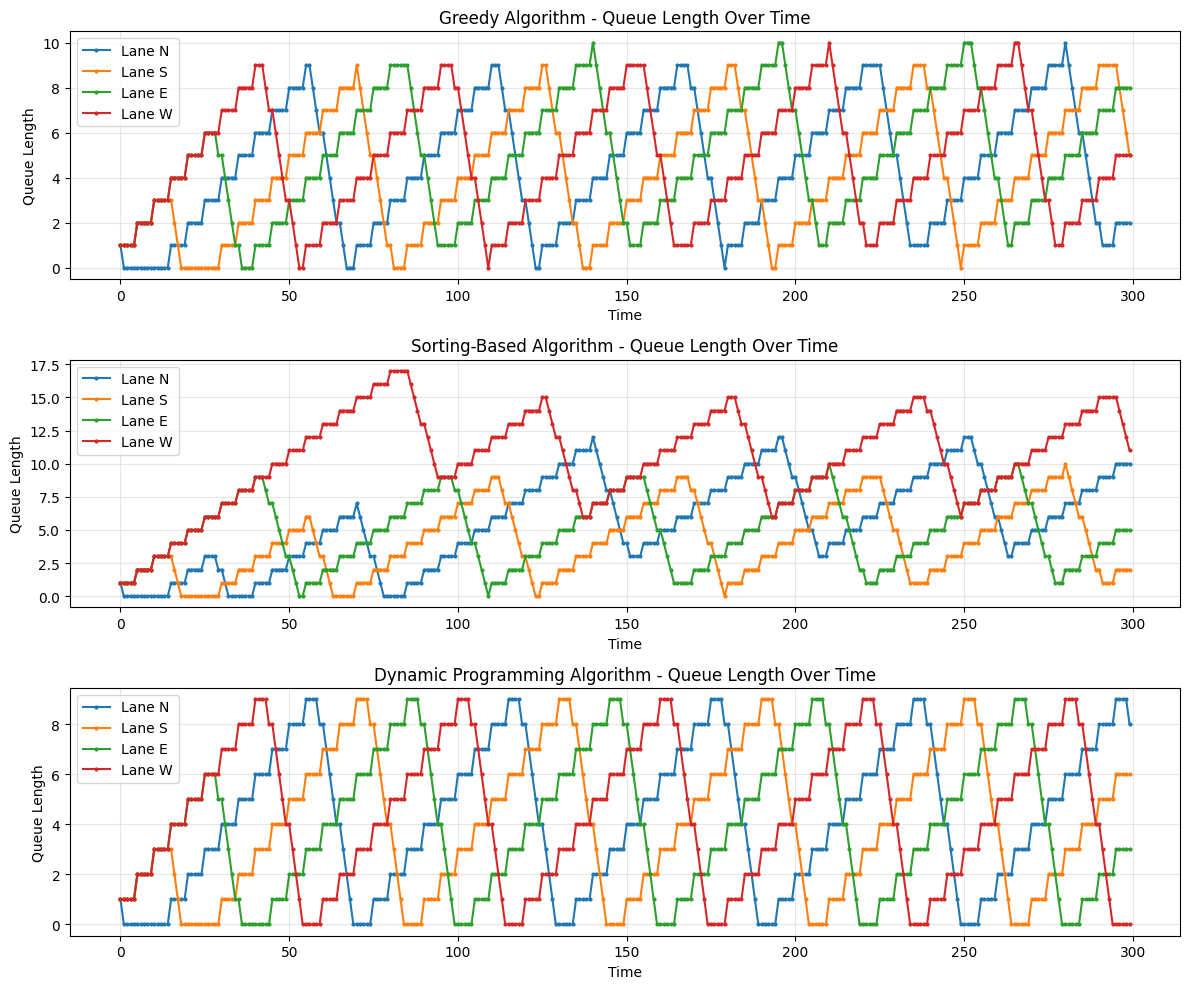

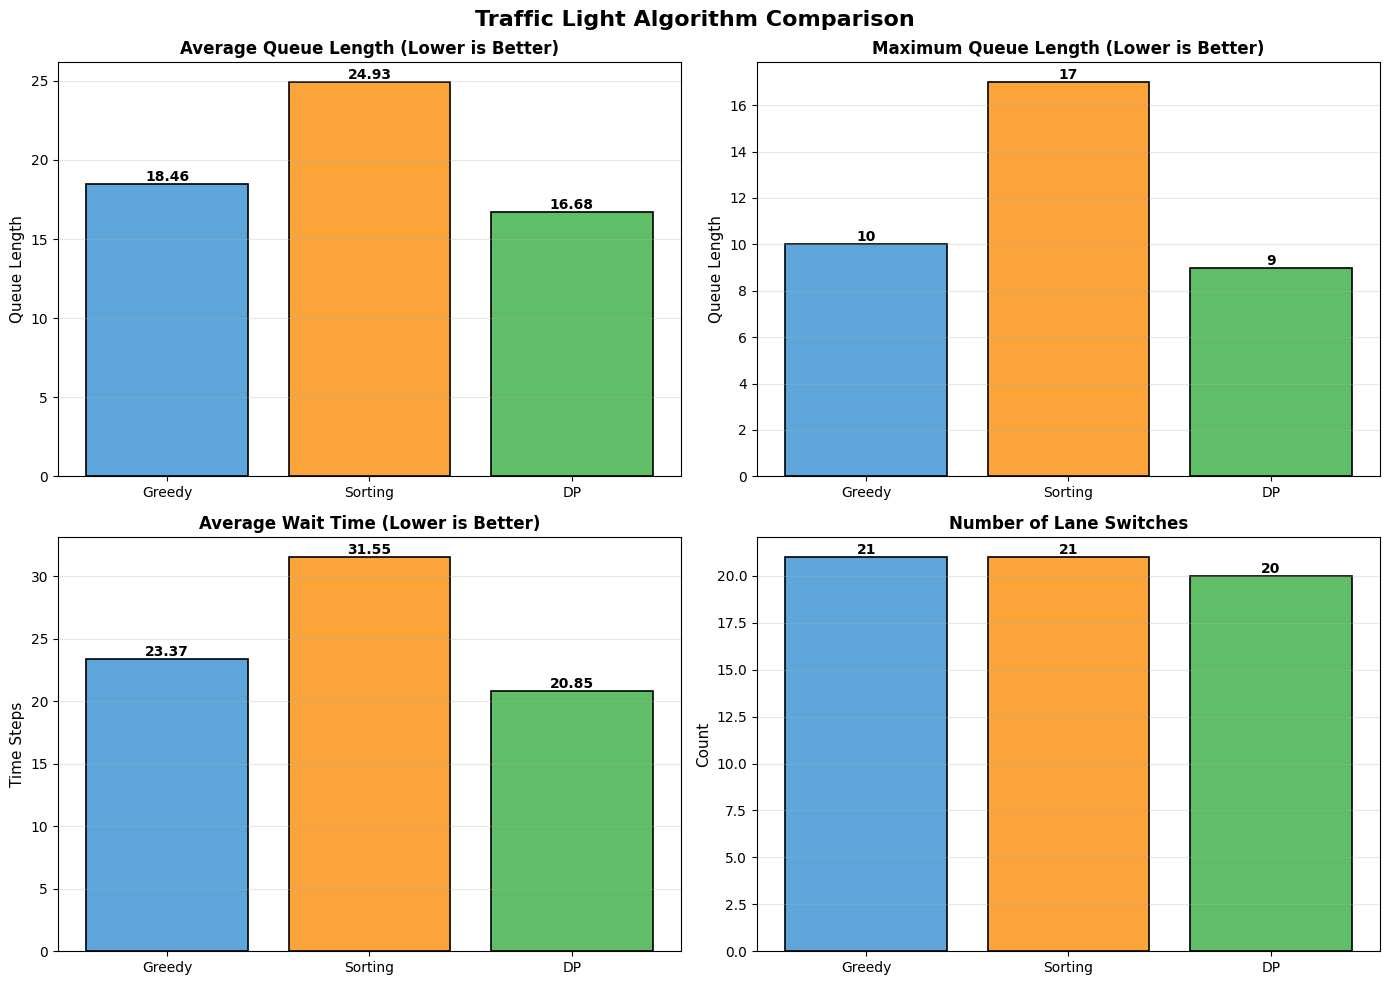


Simulation Complete!


In [14]:
# ==========================================
# RUN EVERYTHING
# ==========================================

# First run the tests
print("PART 1: UNIT TESTS")
print("=" * 60)
run_all_tests()

print("\n\n")

# Then run the main simulation
print("PART 2: MAIN SIMULATION")
print("=" * 60)
main()